# **BMI Calculator**

In [37]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [38]:
# Define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [39]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    # update the state
    state['bmi'] = round(bmi, 2)
    return state


In [40]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state


In [41]:
# Define your graph
# pass state in imput
graph = StateGraph(BMIState)

# Add nodes
# Node name and Function to calculate
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label', label_bmi)

# Add edges
# START & END - dummy node
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label')
graph.add_edge('label', END)

# Compile the graph
workflow = graph.compile()


In [42]:
# Execute
initial_state = {'weight_kg': 80.6, 'height_m': 1.82}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80.6, 'height_m': 1.82, 'bmi': 24.33, 'category': 'Normal'}


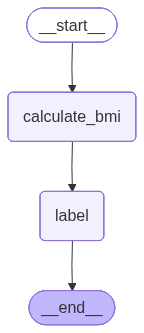

In [43]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# **Simple Workflow** 

In [13]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [14]:
load_dotenv()

model = ChatOpenAI()

In [15]:
# create a state 
class LLMState(TypedDict):
    question: str
    answer: str

In [16]:
def llm_qa(state: LLMState) -> LLMState:
    # extract question
    question = state['question']

    # prompt
    prompt = f"Answer the following question {question}"

    # ask llm
    answer = model.invoke(prompt).content

    # update state
    state['answer'] = answer

    return state

In [17]:
# create graph
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [18]:
initial_state = {'question': 'what is semaphore?'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'what is semaphore?', 'answer': 'A semaphore is a synchronization method used in computer programming to control access to shared resources among multiple threads or processes. It is used to prevent concurrent access to shared resources and ensure that only one thread or process can access a resource at a time. Semaphores can be used to manage and coordinate the execution of multiple threads in a multi-threaded program.'}


# **Prompt Chaining**

In [19]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [20]:
load_dotenv()

model = ChatOpenAI()

In [21]:
# create a state 
class LLMState(TypedDict):
    question: str
    answer: str

In [22]:
def llm_qa(state: LLMState) -> LLMState:
    # extract question
    question = state['question']

    # prompt
    prompt = f"Answer the following question {question}"

    # ask llm
    answer = model.invoke(prompt).content

    # update state
    state['answer'] = answer

    return state

In [23]:
# create graph
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

In [24]:
initial_state = {'question': 'what is semaphore?'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'what is semaphore?', 'answer': 'A semaphore is a synchronization primitive used in concurrent programming to control access to shared resources. It is essentially a variable with an integer value that can be accessed and modified using two atomic operations: wait (P) and signal (V). Semaphores can be used to manage access to critical sections of code, coordinate the activities of multiple threads, and prevent race conditions.'}


In [25]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [26]:
load_dotenv()

model = ChatOpenAI()

In [27]:
# Define state
class BlogState(TypedDict):
    topic: str
    outlines: str
    content: str
    evaluation: float

In [28]:
def generate_outline(state: BlogState) -> BlogState:
    topic = state['topic']
    prompt = f"Generate outlines for the topic {topic} which helps to write a blog on that topic."

    outlines = model.invoke(prompt).content
    state['outlines'] = outlines

    return state

In [29]:
def generate_blog(state: BlogState) -> BlogState:
    topic = state['topic']
    outlines = state['outlines']

    prompt = f"Write a blog based on the topic {topic} and some outlines {outlines} for it."

    content = model.invoke(prompt).content
    state['content'] = content

    return state

In [30]:
def evaluate_blog(state: BlogState) -> BlogState:
    outlines = state['outlines']
    content = state['content']

    prompt = f"Based of these outlines {outlines}, evaluate my blog \n {content} and give a score out-off 10."

    result = model.invoke(prompt).content
    state['evaluation'] = result

    return state

In [31]:
# Graph
graph = StateGraph(BlogState)

graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)
graph.add_node('evaluation', evaluate_blog)

# Add Edges
graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog', 'evaluation')
graph.add_edge('evaluation', END)

workflow = graph.compile()

In [32]:
# Execute
initial_state = {'topic': 'Quantum Physics'}

final_state = workflow.invoke(initial_state)

In [33]:
print(final_state['outlines'])

I. Introduction to Quantum Physics
A. Definition and basic principles
B. Historical background and key figures

II. Fundamentals of Quantum Mechanics
A. Wave-particle duality
B. Quantum superposition
C. Uncertainty principle

III. Quantum Entanglement
A. Definition and implications
B. EPR paradox
C. Applications in quantum computing and teleportation

IV. Quantum Field Theory
A. Introduction to field theory
B. Particle interactions and quantum fields
C. Role of virtual particles

V. Quantum Gravity
A. Problems with combining quantum mechanics and general relativity
B. String theory and other attempts at a quantum theory of gravity
C. Implications for the nature of spacetime

VI. Applications and Future of Quantum Physics
A. Quantum cryptography and secure communication
B. Quantum computing and information processing
C. Emerging technologies and potential breakthroughs

VII. Conclusion
A. Summary of key points
B. Reflection on the significance of quantum physics in modern science and te

In [34]:
print(final_state['content'])

Quantum physics, also known as quantum mechanics, is a branch of physics that explores the behavior of matter and energy on the smallest scales, such as atoms and subatomic particles. This field of study has revolutionized our understanding of the fundamental building blocks of the universe and has led to groundbreaking advancements in technology. In this blog post, we will delve into the fascinating world of quantum physics, exploring its key principles, historical development, and future applications.

I. Introduction to Quantum Physics

A. Definition and basic principles
Quantum physics is based on the principles of quantum mechanics, a theory that describes the behavior of particles at the microscopic level. Key concepts in quantum physics include quantization, wave-particle duality, and superposition.

B. Historical background and key figures
The development of quantum physics can be traced back to the early 20th century, with contributions from groundbreaking scientists such as M

In [35]:
print(final_state['evaluation'])

I would give this blog post a 9 out of 10. It covers a wide range of topics within quantum physics in a clear and informative manner, making it accessible to readers with varying levels of understanding. The structure is well organized, with each section building upon the previous one to provide a comprehensive overview of the subject. The inclusion of historical context, key principles, applications, and future implications makes the post engaging and relevant. Overall, this blog post effectively conveys the significance of quantum physics in modern science and technology.


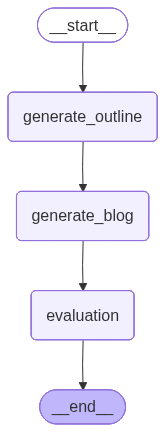

In [36]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png()) 